In [1]:
import os
import cv2
import torch
from torch.utils.data import Dataset
from torchvision import transforms
import pickle

type_dict = {'CLASS A': 0, 'CLASS B': 1, 'CLASS C': 2, 'CLASS D': 3, 'CLASS E': 4, 'CLASS F':5}

IMAGE_FORMAT = ["jpeg", "jpg", "png"]
    
class BlueprintDataset(Dataset):
    def __init__(self, data_dir, transformer=None):
        self.data_dir = data_dir
        self.transformer = transformer
        self.image_paths = self._load_image_paths()

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        norm_path, hidden_path, wireframe_path = self.image_paths[index]

        # 이미지를 실제로 로드하는 대신 경로만 가져옵니다.
        norm_image = norm_path
        hidden_image = hidden_path
        wireframe_image = wireframe_path

        class_name = os.path.basename(os.path.dirname(os.path.dirname(norm_path)))  # 클래스 이름을 가져옵니다.
        class_id = type_dict[class_name]

        if self.transformer:
            # 이미지를 실제로 로드하고 필요한 변환을 수행합니다.
            norm_image = cv2.imread(norm_path)
            norm_image = cv2.cvtColor(norm_image, cv2.COLOR_BGR2RGB)
            hidden_image = cv2.imread(hidden_path)
            hidden_image = cv2.cvtColor(hidden_image, cv2.COLOR_BGR2RGB)
            wireframe_image = cv2.imread(wireframe_path)
            wireframe_image = cv2.cvtColor(wireframe_image, cv2.COLOR_BGR2RGB)

            seed = torch.random.seed()
            torch.random.manual_seed(seed)
            norm_image = self.transformer(norm_image)
            torch.random.manual_seed(seed)
            hidden_image = self.transformer(hidden_image)
            torch.random.manual_seed(seed)
            wireframe_image = self.transformer(wireframe_image)

            class_id = torch.tensor(class_id).long()

        return (norm_image, hidden_image, wireframe_image), class_id

    def _load_image_paths(self):
        image_paths = []
        for class_name in type_dict.keys():
            type_data = image_path_reader(class_name.split()[-1])
            norm_paths = [path for path in type_data['norm']]
            hidden_paths = [path for path in type_data['hidden']]
            wireframe_paths = [path for path in type_data['wireframe']]
            image_paths.extend(zip(norm_paths, hidden_paths, wireframe_paths))
        return image_paths

def image_path_reader(parts_type):
    # 실제 데이터 디렉토리에서 이미지 경로를 읽어오는 함수
    norm = list_image_files(f'./new_raw_240927/CLASS {parts_type}', '01.NORM/')
    temp_hidden = list_image_files(f'./new_raw_240927/CLASS {parts_type}', '02.HIDDEN/')
    temp_wireframe = list_image_files(f'./new_raw_240927/CLASS {parts_type}', '03.WIREFRAME/')
    hidden, wireframe = lst_sorter(norm, temp_hidden, temp_wireframe)
    temp_dict = {'norm': norm, 'hidden': hidden, 'wireframe': wireframe}
    return temp_dict

def list_image_files(data_dir, sub_dir):
    class_id = data_dir.split('/')[-1]
    image_files = []
    images_dir = os.path.join(data_dir, sub_dir)
    
    for file_path in os.listdir(images_dir):
        if file_path.split(".")[-1] in IMAGE_FORMAT:
            image_files.append(os.path.join(images_dir, file_path))
    return image_files

def lst_sorter(norm_lst, hidden_lst, wireframe_lst):
    new_hidden_lst = []
    new_wireframe_lst = []
    for norm in norm_lst:
        image_name = os.path.basename(norm).split('.')[0]
        for hidden, wireframe in zip(hidden_lst, wireframe_lst):
            temp_hidden = os.path.basename(hidden).split('.')[0][:-2]
            temp_wireframe = os.path.basename(wireframe).split('.')[0][:-2]
            if image_name == temp_hidden:
                new_hidden_lst.append(hidden)
            if image_name == temp_wireframe:
                new_wireframe_lst.append(wireframe)
    return new_hidden_lst, new_wireframe_lst

# 예시로 사용할 수 있는 transformer
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((512, 512)),
    transforms.RandomVerticalFlip(.5),
    transforms.RandomHorizontalFlip(.5),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# 데이터셋 생성
dataset = BlueprintDataset('./new_raw_240927', transformer=transform)

# 데이터셋 사용 예시
for i in range(len(dataset)):
  sample, class_id = dataset[i]
  # 여기서 sample과 class_id를 사용하여 모델 학습 등을 수행할 수 있습니다.
  #print(sample, class_id)
  break

In [2]:
import torch
from torch.utils.data import DataLoader, random_split
from tqdm.notebook import tqdm
import numpy as np
import matplotlib.pyplot as plt
import random

seed = 23

train_size = int(len(dataset) * 0.8)
valid_size = len(dataset) - train_size
#valid_size = int(len(dataset) * 0.2)
#test_size = len(dataset) - train_size - valid_size

#train_dataset, valid_dataset, test_dataset = random_split(dataset, [train_size, valid_size, test_size])
train_dataset, valid_dataset = random_split(dataset, [train_size, valid_size])

train_loader = DataLoader(train_dataset, shuffle = False, batch_size = 1)
valid_loader = DataLoader(valid_dataset, shuffle = True, batch_size = 1)
#test_loader = DataLoader(test_dataset, shuffle = False, batch_size = 1)

In [3]:
train_class_num = {f'{i}':0 for i in range(6)}
valid_class_num = {f'{i}':0 for i in range(6)}
test_class_num = {f'{i}':0 for i in range(6)}

for _, y in tqdm(train_loader):
    train_class_num[f'{y.item()}'] += 1

for _, y in tqdm(valid_loader):
    valid_class_num[f'{y.item()}'] += 1
    
for _, y in tqdm(test_loader):
    test_class_num[f'{y.item()}'] += 1

  0%|          | 0/3315 [00:00<?, ?it/s]

  0%|          | 0/829 [00:00<?, ?it/s]

NameError: name 'test_loader' is not defined

In [ ]:
inv_type_dict = {0 : 'CLASS A', 1 : 'CLASS B', 2 : 'CLASS C', 3 : 'CLASS D', 4 : 'CLASS E', 5 : 'CLASS F'}
print('#### train ####')
for idx, class_num in train_class_num.items():
    print(inv_type_dict[int(idx)], class_num)
print('#### valid ####')
for idx, class_num in valid_class_num.items():
    print(inv_type_dict[int(idx)], class_num)
    
print('#### test ####')
for idx, class_num in test_class_num.items():
    print(inv_type_dict[int(idx)], class_num)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


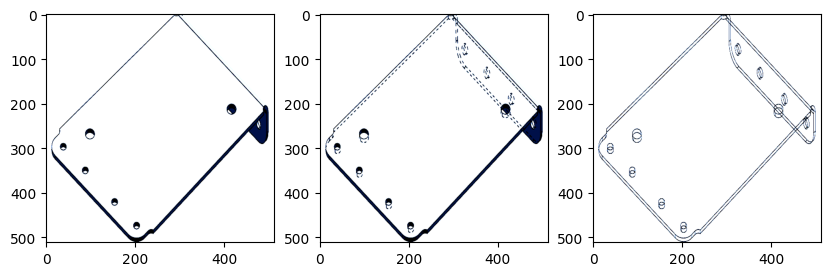

In [6]:
for (x1, x2, x3), y in train_loader:
    break

plt.figure(figsize = (10,5))
for i, x in enumerate([x1,x2,x3]):
    plt.subplot(1,3,i+1)
    plt.imshow(np.transpose(x.numpy()[0], (1,2,0)))

In [3]:
from torchvision.models import resnext50_32x4d
from torch import nn
import torch
from torchsummary import summary

model = resnext50_32x4d(weights = 'ResNeXt50_32X4D_Weights.IMAGENET1K_V2')
model.fc = nn.Linear(2048, 6, bias = True)

In [4]:
def train(model, loader, criterion, optimizer, scheduler):
    '''
    학습을 위한 함수
    '''
    model.train()
    train_loss = 0.
    train_acc = 0.
    
    with tqdm(loader, unit='batch') as tepoch:
        for (x1, _, _), y in tepoch:  # 추가적인 입력은 무시
            tepoch.set_description('Training')
            
            x1 = x1.to(device)
            y = y.to(device)
        
            y_hat = model(x1)
            loss = criterion(y_hat, y)
        
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            if scheduler is not None:
                scheduler.step()
            
            # loss
            train_loss += loss.item()
            
            # acc
            pred = y_hat.max(1, keepdim=True)[1]
            iter_acc = pred.eq(y.data.view_as(pred)).sum().item()
            train_acc += iter_acc
            
            tepoch.set_postfix(loss=loss.item(), acc=iter_acc)
    
    train_loss = train_loss / len(loader)
    train_acc = train_acc / len(loader.dataset)
    
    return train_loss, train_acc


def valid(model, loader, criterion):
    '''
    검증을 위한 함수
    '''
    model.eval()
    val_loss = 0.
    val_acc = 0.
    
    with tqdm(loader, unit='batch') as tepoch:
        with torch.no_grad():
            for (x1, _, _), y in tepoch:  # 추가적인 입력은 무시
                tepoch.set_description('Evaluation')
                
                x1 = x1.to(device)
                y = y.to(device)
            
                y_hat = model(x1)
                loss = criterion(y_hat, y)
                val_loss += loss.item()
                
                # acc
                pred = y_hat.max(1, keepdim=True)[1]
                iter_acc = pred.eq(y.data.view_as(pred)).sum().item()
                val_acc += iter_acc
                
                tepoch.set_postfix(loss=loss.item(), acc=iter_acc)
    
    val_loss = val_loss / len(loader)
    val_acc = val_acc / len(loader.dataset)
    
    return val_loss, val_acc

In [5]:
train_loader = DataLoader(train_dataset, shuffle = True, batch_size = 8)
valid_loader = DataLoader(valid_dataset, shuffle = False, batch_size = 4)
#test_loader = DataLoader(test_dataset, shuffle = False, batch_size = 4)

device = 'cuda:0'
optimizer = torch.optim.SGD(model.parameters(), lr = 0.001, momentum = 0.9)
model = model.to(device)

In [10]:
from tqdm.notebook import tqdm

criterion = nn.CrossEntropyLoss().to(device)
n_epoch = 100
low_acc = 0.0

train_loss_lst = []
valid_loss_lst = []

train_acc_lst = []
valid_acc_lst = []


for epoch in range(n_epoch):
    train_loss, train_acc = train(model = model, 
                                loader = train_loader, 
                                criterion = criterion,
                                optimizer = optimizer,
                                scheduler = None)
    
    valid_loss, valid_acc = valid(model = model,
                                 loader = valid_loader, 
                                 criterion = criterion)
    
    train_loss_lst.append(train_loss)
    valid_loss_lst.append(valid_loss)

    train_acc_lst.append(train_acc)
    valid_acc_lst.append(valid_acc)
    
    print(f'Epoch {epoch+1} ==> train_loss : {train_loss:.3f}, train acc : {train_acc * 100:.2f}%')
    print(f'                ==> valid_loss : {valid_loss:.3f}, valid acc : {valid_acc * 100:.2f}%')
    
    if valid_acc > low_acc:
        print('+')
        print('valid acc가 향상되었습니다. 모델저장!!!')
        torch.save({
            'Epoch' : epoch+1,
            'model_state_dict' : model.state_dict(),
            'optimizer_state_dict' : optimizer.state_dict()}, f'./ckpts/case1_resnext50_512/best_pt.pth')
        low_acc = valid_acc
    else:
        print('+')
        print('valid acc가 향상되지 않았습니다!!!')
    
    torch.save({
        'Epoch' : epoch + 1,
        'model_state_dict' : model.state_dict(),
        'optimizer_state_dict' : optimizer.state_dict()}, f'./ckpts/case1_resnext50_512/last_pt.pth')

result_dict = {}
result_dict['train_loss'] = train_loss_lst
result_dict['valid_loss'] = valid_loss_lst
result_dict['train_acc'] = train_acc_lst
result_dict['valid_acc'] = valid_acc_lst

#with open(f'./ckpts/{type_name}/result_dict.pickle','wb') as p:
#    pickle.dump(result_dict, p)

  0%|          | 0/415 [00:00<?, ?batch/s]

  0%|          | 0/208 [00:00<?, ?batch/s]

Epoch 1 ==> train_loss : 1.766, train acc : 21.60%
                ==> valid_loss : 1.707, valid acc : 27.26%
+
valid acc가 향상되었습니다. 모델저장!!!


  0%|          | 0/415 [00:00<?, ?batch/s]

  0%|          | 0/208 [00:00<?, ?batch/s]

...

  0%|          | 0/208 [00:00<?, ?batch/s]

Epoch 99 ==> train_loss : 0.003, train acc : 99.97%
                ==> valid_loss : 0.497, valid acc : 89.02%
+
valid acc가 향상되지 않았습니다!!!


  0%|          | 0/415 [00:00<?, ?batch/s]

  0%|          | 0/208 [00:00<?, ?batch/s]

Epoch 100 ==> train_loss : 0.001, train acc : 100.00%
                ==> valid_loss : 0.544, valid acc : 88.30%
+
valid acc가 향상되지 않았습니다!!!


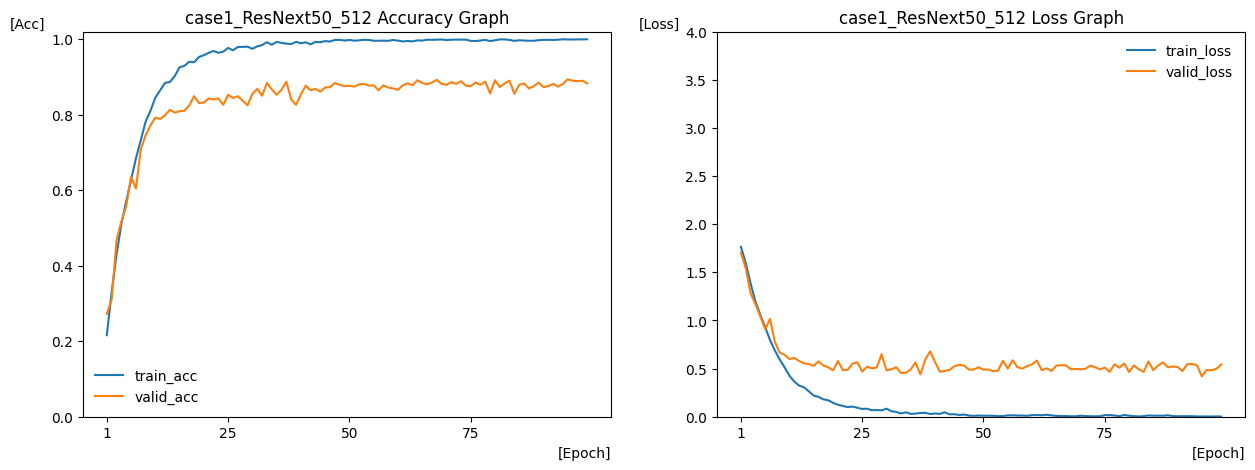

In [11]:
plt.figure(figsize = (15,5))
plt.subplot(1,2,1)
plt.plot(train_acc_lst, label = 'train_acc')
plt.plot(valid_acc_lst, label = 'valid_acc')
plt.ylabel('[Acc]', loc = 'top', rotation = 360)
plt.xlabel('[Epoch]', loc = 'right')
plt.legend(frameon = False)
plt.xticks([i*25 for i in range(4)], [1]+[i*25 for i in range(1,4)])
plt.title('case1_ResNext50_512 Accuracy Graph')
plt.ylim(0,1.02)
plt.subplot(1,2,2)
plt.plot(train_loss_lst, label = 'train_loss')
plt.plot(valid_loss_lst, label = 'valid_loss')
plt.ylabel('[Loss]', loc = 'top', rotation = 360)
plt.xlabel('[Epoch]', loc = 'right')
plt.legend(frameon = False)
plt.xticks([i*25 for i in range(4)], [1]+[i*25 for i in range(1,4)])
plt.title('case1_ResNext50_512 Loss Graph')
plt.ylim(0,4)
plt.show()

In [14]:
model.load_state_dict(torch.load(f'./ckpts/case1_resnext50_512/best_pt.pth')['model_state_dict'])

test_loss, test_acc = valid(model = model,
                              loader = valid_loader, 
                              criterion = criterion)
test_acc

C:\Users\user\AppData\Local\Temp\ipykernel_28704\2928241712.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f'./ckpts/case1_resnext50_51

  0%|          | 0/208 [00:00<?, ?batch/s]

0.8769601930036188

In [6]:
import torch
from torchvision.models import resnext50_32x4d

# ResNeXt50 모델 정의
model = resnext50_32x4d(pretrained=False)
model.fc = torch.nn.Linear(2048, 6)  # 출력 클래스 수 수정 (예: 10)

# 체크포인트 로드
checkpoint = torch.load('./ckpts/case1_resnext50_384/best_pt.pth')
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print("모델이 성공적으로 로드되었습니다!")

c:\Users\user\.conda\envs\topimage\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\user\.conda\envs\topimage\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
C:\Users\user\AppData\Local\Temp\ipykernel_29596\4004630553.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_o

모델이 성공적으로 로드되었습니다!


In [7]:
from sklearn.metrics import f1_score
import torch
from torch.utils.data import DataLoader, Dataset

In [8]:
from sklearn.metrics import f1_score
import torch
from tqdm import tqdm

def evaluate_f1_score(model, data_loader):
    model.eval()  # 평가 모드
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for (norm_image, hidden_image, wireframe_image), labels in tqdm(data_loader):
            # 3채널 이미지를 하나로 병합하는 경우 (옵션)
            inputs = torch.cat([norm_image], dim=1)  # (B, 9, H, W)

            # 모델 예측
            outputs = model(inputs)
            preds = torch.argmax(outputs, dim=1)  # 가장 높은 확률의 클래스를 선택

            # 예측값과 실제값 저장
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # F1-Score 계산
    f1 = f1_score(all_labels, all_preds, average='weighted')  # 'weighted', 'macro', 'micro' 중 선택
    print(f"F1-Score: {f1}")
    return f1

# 평가 예시
# train_loader 또는 valid_loader를 전달
f1_train = evaluate_f1_score(model, train_loader)
f1_valid = evaluate_f1_score(model, valid_loader)

100%|██████████| 415/415 [10:51<00:00,  1.57s/it]


F1-Score: 0.9366475125081298


100%|██████████| 208/208 [02:32<00:00,  1.36it/s]

F1-Score: 0.9218435110169202
